# EXP4: ProPicker Rotation Invariance Analysis

This experiment evaluates whether ProPicker is invariant to particle rotations.

## Objectives

1. **Test rotation invariance**: Run 10 inferences per checkpoint using prompts with different rotations
2. **Compare checkpoint types**:
   - Base model (no fine-tuning)
   - Single-instance prompt fine-tuned models (from EXP3)
   - Multi-instance prompt fine-tuned models (from EXP3)

## Methodology

1. **Prompt Selection**: Select 10 prompts with diverse rotations from the CSV:
   - Filter thyroglobulin particles (Label=7)
   - Apply EXP3's selection criteria (valid bounds, good signal)
   - Ensure diverse rotations using quaternion angular distance (min 30°)

2. **Inference**: For each checkpoint and each prompt, run inference on validation set

3. **Analysis**: Compare performance (Precision, Recall, F1) across:
   - Base vs Single-prompt increments
   - Base vs Multi-prompt increments  
   - Single-prompt vs Multi-prompt increments

## Expected Outcome

If ProPicker is rotation-invariant, performance should be consistent across all prompts regardless of their rotation.

In [1]:
import sys
from pathlib import Path

# Add project root and experiments to path
PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

# Import paths
from paths import (
    UMU_SYNTH_DIR,
    UMU_SYNTH_TOMOS_DIR,
    UMU_SYNTH_CSV,
    TOMOTWIN_MODEL_FILE,
    PROPICKER_TOOLS_DIR,
    PROPICKER_MODEL_FILE,
    EXP3_RESULTS_DIR,
    EXP3_CHECKPOINTS_DIR,
    EXP3_COORDS_DIR,
    EXP4_RESULTS_DIR,
    EXP4_DATA_DIR,
    EXP4_PROMPTS_DIR,
    EXP4_INFERENCE_DIR,
    EXP4_COORDS_DIR,
)

# Import config
from experiments.config import (
    setup_propicker_paths,
    THYROGLOBULIN_NAME,
    THYROGLOBULIN_LABEL,
    PROMPT_SIZE,
    PROMPT_HALF,
    THYROGLOBULIN_DIAMETER,
    EXP4_VAL_TOMOS,
    EXP4_TRAIN_POOL,
    EXP4_NUM_PROMPTS,
    EXP4_MIN_ANGULAR_DISTANCE,
    EXP3_INCREMENTS,
)

# Setup ProPicker imports
PROPICKER_DIR = setup_propicker_paths()

import subprocess
import json
import pandas as pd
import numpy as np
import torch
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.spatial.transform import Rotation
from scipy.spatial.distance import cdist

from inference.tomotwin import pass_subtomos_through_tomotwin
from utils.mrctools import load_mrc_data

import warnings
warnings.filterwarnings("ignore")

# Create output directories
EXP4_DATA_DIR.mkdir(parents=True, exist_ok=True)
EXP4_PROMPTS_DIR.mkdir(parents=True, exist_ok=True)
EXP4_COORDS_DIR.mkdir(parents=True, exist_ok=True)

print(f"ProPicker tools: {PROPICKER_DIR}")
print(f"UMU Synth data: {UMU_SYNTH_DIR}")
print(f"EXP3 checkpoints: {EXP3_CHECKPOINTS_DIR}")
print(f"EXP4 results: {EXP4_RESULTS_DIR}")
print(f"EXP4 data dir: {EXP4_DATA_DIR}")
print(f"\nExperiment parameters:")
print(f"  Validation tomograms: {EXP4_VAL_TOMOS}")
print(f"  Number of prompts: {EXP4_NUM_PROMPTS}")
print(f"  Min angular distance: {EXP4_MIN_ANGULAR_DISTANCE}°")
print(f"  Prompt size: {PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE}")

ProPicker tools: /home/carloshg/Dev/cryoet-particle-picking/tools/ProPicker/propicker
UMU Synth data: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth
EXP3 checkpoints: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/checkpoints
EXP4 results: /home/carloshg/Dev/cryoet-particle-picking/results/exp4_ppicker_rotations
EXP4 data dir: /home/carloshg/Dev/cryoet-particle-picking/results/exp4_ppicker_rotations/data

Experiment parameters:
  Validation tomograms: ['tomo_rec_5_snr1.66', 'tomo_rec_6_snr1.17', 'tomo_rec_7_snr1.13', 'tomo_rec_8_snr0.57', 'tomo_rec_9_snr1.28']
  Number of prompts: 10
  Min angular distance: 30.0°
  Prompt size: 37×37×37


## Step 0: Update CSV Paths

The CSV file contains paths from the original system. We need to update the `Tomo3D` column to point to our local data directory using the `update_csv_paths.py` script.

In [2]:
# Path to the update script (reuse from exp3)
UPDATE_SCRIPT = PROJECT_ROOT / "experiments" / "exp3_ppicker_limits" / "scripts" / "update_csv_paths.py"

# Output CSV with updated paths
UPDATED_CSV = EXP4_DATA_DIR / "tomos_motif_list_updated.csv"

# Run the script to update paths (dry-run first to preview)
print("Preview of path changes (dry-run):")
cmd_preview = [
    "python", str(UPDATE_SCRIPT),
    str(UMU_SYNTH_CSV),
    "--columns", "Tomo3D",
    "--new-dir", str(UMU_SYNTH_TOMOS_DIR),
    "--dry-run"
]
result = subprocess.run(cmd_preview, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

Preview of path changes (dry-run):
[DRY RUN] Processing file: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos_motif_list.csv
Columns to update: Tomo3D
New directory: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos
Delimiter: TAB
--------------------------------------------------------------------------------
Header found: 15 columns
  - 'Tomo3D' (index 3)
--------------------------------------------------------------------------------
Column 'Tomo3D':
  Before:  /home/aguilar/Projects/polnet/data/data_generated/25_more_ribos_and_distractors/tomos/tomo_rec_0_snr1.63.mrc
  After: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos/tomo_rec_0_snr1.63.mrc
Column 'Tomo3D':
  Before:  /home/aguilar/Projects/polnet/data/data_generated/25_more_ribos_and_distractors/tomos/tomo_rec_0_snr1.63.mrc
  After: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos/tomo_rec_0_snr1.63.mrc
Column 'Tomo3D':
  Before:  /home/aguilar/Projects/polnet/data/

In [3]:
# Apply the path update (this creates the updated CSV)
print("Applying path update...")
cmd_apply = [
    "python", str(UPDATE_SCRIPT),
    str(UMU_SYNTH_CSV),
    "--columns", "Tomo3D",
    "--new-dir", str(UMU_SYNTH_TOMOS_DIR),
    "--output", str(UPDATED_CSV)
]
result = subprocess.run(cmd_apply, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

print(f"\n✅ Updated CSV saved to: {UPDATED_CSV}")

Applying path update...
Processing file: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos_motif_list.csv
Columns to update: Tomo3D
New directory: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos
Delimiter: TAB
--------------------------------------------------------------------------------
Header found: 15 columns
  - 'Tomo3D' (index 3)
--------------------------------------------------------------------------------
Processed 100,000 rows...
Processed 200,000 rows...
Processed 300,000 rows...
Processed 400,000 rows...
Processed 500,000 rows...
Processed 600,000 rows...
Processed 700,000 rows...
Processed 800,000 rows...
Processed 900,000 rows...
Processed 1,000,000 rows...
Processed 1,100,000 rows...
Processed 1,200,000 rows...
Processed 1,300,000 rows...
Processed 1,400,000 rows...
Processed 1,500,000 rows...
Processed 1,600,000 rows...
Processed 1,700,000 rows...
Processed 1,800,000 rows...
Processed 1,900,000 rows...
Processed 2,000,000 rows...
Processe

## Step 1: Load and Filter Thyroglobulin Data

Load the updated CSV and filter for thyroglobulin instances (Label=7). Group by tomogram (Tomo3D column) and extract coordinates and rotations.

**IMPORTANT**: CSV coordinates are in Angstroms, they need to be converted to voxels for subtomogram extraction.

In [4]:
print("=" * 70)
print("LOADING PARTICLE DATA FROM CSV")
print("=" * 70)

# Load the updated CSV (with corrected paths)
print(f"Loading CSV from: {UPDATED_CSV}")
df_all = pd.read_csv(UPDATED_CSV, sep='\t')

print(f"Total entries in CSV: {len(df_all)}")
print(f"Columns: {list(df_all.columns)}")

# Filter thyroglobulin particles (Label = 7)
df_thy = df_all[df_all['Label'] == THYROGLOBULIN_LABEL].copy()
print(f"\nThyroglobulin particles (Label={THYROGLOBULIN_LABEL}): {len(df_thy)}")

# Check for quaternion columns
quat_cols = ['Q1', 'Q2', 'Q3', 'Q4']
print(f"\nQuaternion columns present: {all(col in df_thy.columns for col in quat_cols)}")

# Display sample
print("\nSample thyroglobulin entries:")
display_cols = ['Tomo3D', 'X', 'Y', 'Z', 'Q1', 'Q2', 'Q3', 'Q4']
df_thy[display_cols].head(10)

LOADING PARTICLE DATA FROM CSV
Loading CSV from: /home/carloshg/Dev/cryoet-particle-picking/results/exp4_ppicker_rotations/data/tomos_motif_list_updated.csv
Total entries in CSV: 6094626
Columns: ['Density', 'Micrographs', 'PolyData', 'Tomo3D', 'Type', 'Label', 'Code', 'Polymer', 'X', 'Y', 'Z', 'Q1', 'Q2', 'Q3', 'Q4']

Thyroglobulin particles (Label=7): 3327

Quaternion columns present: True

Sample thyroglobulin entries:


,Tomo3D,X,Y,Z,Q1,Q2,Q3,Q4
231169,/home/carloshg/Dev/cryoet-particle-picking/dat...,5728.335281,2944.048807,887.945627,-0.573456,-0.222942,0.775774,0.140067
231170,/home/carloshg/Dev/cryoet-particle-picking/dat...,3459.548995,5800.046534,1499.429777,-0.894171,-0.425035,0.123031,-0.068323
231171,/home/carloshg/Dev/cryoet-particle-picking/dat...,5960.459624,2534.072272,1287.858824,-0.263044,0.038844,0.938775,0.219092
231172,/home/carloshg/Dev/cryoet-particle-picking/dat...,626.756302,3820.667673,638.055835,-0.989615,-0.042427,-0.057551,0.124702
231173,/home/carloshg/Dev/cryoet-particle-picking/dat...,2768.743966,2923.076532,498.914747,0.792198,0.476430,0.286986,0.251148
231174,/home/carloshg/Dev/cryoet-particle-picking/dat...,1302.668773,3475.657959,939.592144,-0.475269,0.468086,-0.606494,-0.432642
231175,/home/carloshg/Dev/cryoet-particle-picking/dat...,1475.456728,5953.252267,868.229292,-0.539651,0.110784,-0.327885,0.767460
231176,/home/carloshg/Dev/cryoet-particle-picking/dat...,4302.067821,5439.559266,1630.537155,0.478978,0.442570,0.738418,0.171613
231177,/home/carloshg/Dev/cryoet-particle-picking/dat...,5359.251414,1224.846739,933.676841,-0.256154,-0.719059,-0.157582,0.626504
231178,/home/carloshg/Dev/cryoet-particle-picking/dat...,4708.057302,4751.190493,1104.879489,0.044501,0.902999,-0.409990,0.120497


In [5]:
# Extract tomogram name from path
def extract_tomo_name(tomo_path):
    """Extract tomogram name from full path in CSV."""
    # Path format: .../tomos/tomo_rec_X_snrY.Z.mrc
    import os
    basename = os.path.basename(tomo_path)
    return basename.replace('.mrc', '')

df_thy['tomo_name'] = df_thy['Tomo3D'].apply(extract_tomo_name)

# Filter to training pool tomograms only (exclude validation set)
df_train = df_thy[df_thy['tomo_name'].isin(EXP4_TRAIN_POOL)].copy()
print(f"Thyroglobulin particles in training pool: {len(df_train)}")
print(f"Unique tomograms: {df_train['tomo_name'].nunique()}")

# Show distribution per tomogram
tomo_counts = df_train.groupby('tomo_name').size().sort_values(ascending=False)
print(f"\nParticles per tomogram:")
print(tomo_counts)

Thyroglobulin particles in training pool: 2705
Unique tomograms: 20

Particles per tomogram:
tomo_name
tomo_rec_10_snr0.97    153
tomo_rec_14_snr0.43    150
tomo_rec_20_snr0.73    150
tomo_rec_24_snr1.39    149
tomo_rec_0_snr1.63     148
tomo_rec_11_snr1.41    148
tomo_rec_16_snr0.93    148
tomo_rec_19_snr1.62    144
tomo_rec_12_snr1.39    143
tomo_rec_18_snr0.78    142
tomo_rec_17_snr0.92    136
tomo_rec_4_snr1.85     133
tomo_rec_3_snr0.63     124
tomo_rec_21_snr0.34    122
tomo_rec_2_snr1.07     122
tomo_rec_23_snr0.29    122
tomo_rec_22_snr0.97    119
tomo_rec_15_snr1.03    118
tomo_rec_1_snr1.46     118
tomo_rec_13_snr1.1     116
dtype: int64


In [6]:
# Extract coordinates and rotations per tomogram
# Columns: X, Y, Z for coordinates; Q1, Q2, Q3, Q4 for rotation quaternions
# IMPORTANT: CSV coordinates are in ANGSTROMS, need to convert to voxels

import mrcfile

# Group by tomogram path
tomo_groups = df_thy.groupby('Tomo3D')

coords_by_tomo = {}
for tomo_path, group in tomo_groups:
    tomo_name = Path(tomo_path).stem
    
    # Read voxel size from MRC header to convert Angstroms -> voxels
    with mrcfile.open(tomo_path, mode='r') as mrc:
        voxel_size = float(mrc.voxel_size.x)  # Assuming isotropic voxels (~10 Å)
    
    # Get coordinates in Angstroms from CSV
    coords_angstrom = group[['X', 'Y', 'Z']].values.astype(np.float32)
    
    # Convert to voxel coordinates
    coords_voxels = coords_angstrom / voxel_size
    
    coords_data = {
        'coords': coords_voxels,
        'coords_angstrom': coords_angstrom,  # Keep original for reference
        'quaternions': group[['Q1', 'Q2', 'Q3', 'Q4']].values.astype(np.float32),
        'tomo_path': tomo_path,
        'voxel_size': voxel_size
    }
    coords_by_tomo[tomo_name] = coords_data

# Save coordinates to files for later use
print("Saving coordinates per tomogram...")
for tomo_name, data in coords_by_tomo.items():
    coord_file = EXP4_COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    coord_df = pd.DataFrame({
        'X': data['coords'][:, 0],
        'Y': data['coords'][:, 1],
        'Z': data['coords'][:, 2],
        'Q1': data['quaternions'][:, 0],
        'Q2': data['quaternions'][:, 1],
        'Q3': data['quaternions'][:, 2],
        'Q4': data['quaternions'][:, 3],
    })
    coord_df.to_csv(coord_file, index=False)
    
print(f"✅ Saved coordinates for {len(coords_by_tomo)} tomograms to {EXP4_COORDS_DIR}")

# Show sample data with conversion info
sample_tomo = list(coords_by_tomo.keys())[0]
sample_data = coords_by_tomo[sample_tomo]
print(f"\nSample data from {sample_tomo}:")
print(f"  Voxel size: {sample_data['voxel_size']:.4f} Å")
print(f"  Coordinates shape: {sample_data['coords'].shape}")
print(f"  First 3 coords (Angstroms): {sample_data['coords_angstrom'][:3]}")
print(f"  First 3 coords (voxels):    {sample_data['coords'][:3]}")
print(f"  Coord range X (voxels): {sample_data['coords'][:, 0].min():.1f} - {sample_data['coords'][:, 0].max():.1f}")
print(f"  Coord range Y (voxels): {sample_data['coords'][:, 1].min():.1f} - {sample_data['coords'][:, 1].max():.1f}")
print(f"  Coord range Z (voxels): {sample_data['coords'][:, 2].min():.1f} - {sample_data['coords'][:, 2].max():.1f}")

Saving coordinates per tomogram...
✅ Saved coordinates for 25 tomograms to /home/carloshg/Dev/cryoet-particle-picking/results/exp4_ppicker_rotations/coords

Sample data from tomo_rec_0_snr1.63:
  Voxel size: 10.0124 Å
  Coordinates shape: (148, 3)
  First 3 coords (Angstroms): [[5728.3354 2944.0488  887.9456]
 [3459.549  5800.0464 1499.4298]
 [5960.4595 2534.0723 1287.8588]]
  First 3 coords (voxels):    [[572.1216  294.03897  88.6842 ]
 [345.52493 579.28375 149.75662]
 [595.3051  253.09227 128.62581]]
  Coord range X (voxels): 11.1 - 616.0
  Coord range Y (voxels): 15.4 - 617.8
  Coord range Z (voxels): 11.0 - 172.3


## Step 2: Select Prompts with Rotation Diversity and Quality Criteria

We select particles using a two-stage approach:

1. **Quality filtering**: Compute quality scores for each particle based on:
   - **Frequency structure ratio**: Mid-band vs high-band power (structure vs noise)
   - **Centre-border ratio**: Energy in centre vs edges (well-centred particles)
   - **DC penalty**: Penalise strong global offset/gradient (ice or artefacts)
   
   Only particles above a quality percentile threshold are considered.

2. **Rotation diversity**: From the high-quality candidates, greedily select particles
   that maximize angular distance between their quaternion rotations.

This ensures we get **both high-quality subtomograms AND diverse orientations**.

In [7]:
def quaternion_angular_distance(q1, q2):
    """
    Compute the angular distance between two quaternions in degrees.
    
    Args:
        q1, q2: Quaternions as [q1, q2, q3, q4] (scalar-last convention)
        
    Returns:
        Angular distance in degrees
    """
    # Normalize quaternions
    q1 = np.array(q1) / np.linalg.norm(q1)
    q2 = np.array(q2) / np.linalg.norm(q2)
    
    # Compute dot product
    dot = np.abs(np.dot(q1, q2))
    
    # Clamp to valid range
    dot = np.clip(dot, -1.0, 1.0)
    
    # Angular distance
    angle_rad = 2 * np.arccos(dot)
    angle_deg = np.degrees(angle_rad)
    
    return angle_deg


# -----------------------------------------------------------------------------
# Quality Scoring Functions (adapted from exp3)
# -----------------------------------------------------------------------------

def _to_numpy(x):
    """Convert torch.Tensor to numpy or pass through arrays."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().float().numpy()
    return np.asarray(x, dtype=np.float32)


def _robust_norm(vol, eps=1e-6):
    """Robust z-score normalisation using median and MAD."""
    v = vol.astype(np.float32, copy=False)
    med = np.median(v)
    mad = np.median(np.abs(v - med)) * 1.4826  # 1.4826 ≈ STD if normal
    return (v - med) / (mad + eps)


def _center_border_ratio(vol, border=4, centre_frac=0.45, eps=1e-6):
    """
    Ratio of average absolute intensity in the central cube to that in a
    surrounding border shell. A well-centred particle has more energy in the
    middle and less on the borders.
    """
    m = vol.shape[0]
    a = np.abs(vol)
    # Border shell mask
    b = border
    border_mask = np.zeros((m, m, m), dtype=bool)
    border_mask[:b, :, :] = True
    border_mask[-b:, :, :] = True
    border_mask[:, :b, :] = True
    border_mask[:, -b:, :] = True
    border_mask[:, :, :b] = True
    border_mask[:, :, -b:] = True
    # Centre cube mask
    c = int(round(m * centre_frac))
    c = max(3, min(c, m))
    s = (m - c) // 2
    centre_mask = np.zeros((m, m, m), dtype=bool)
    centre_mask[s:s+c, s:s+c, s:s+c] = True
    centre_energy = a[centre_mask].mean()
    border_energy = a[border_mask].mean()
    return (centre_energy + eps) / (border_energy + eps)


def _freq_structure_ratio(vol, k_low=0.08, k_high=0.30, eps=1e-8):
    """
    Ratio of mid-band power (structure) to high-band power (noise) in the
    Fourier magnitude spectrum. Higher ratio → more signal.
    """
    m = vol.shape[0]
    F = np.fft.fftn(vol)
    P = (np.abs(F) ** 2).astype(np.float64)
    # Normalised radial frequency grid
    f = np.fft.fftfreq(m)
    kx, ky, kz = np.meshgrid(f, f, f, indexing='ij')
    k = np.sqrt(kx**2 + ky**2 + kz**2)
    k = k / (k.max() + eps)
    mid = (k >= k_low) & (k < k_high)
    high = (k >= k_high)
    E_mid = P[mid].sum()
    E_high = P[high].sum()
    return (E_mid + eps) / (E_high + eps)


def _dc_penalty(vol, eps=1e-6):
    """Penalise strong global offset/gradient (ice or missing wedge artefacts)."""
    return np.abs(vol.mean()) / (vol.std() + eps)


def compute_quality_score(
    subtomo,
    border=4,
    centre_frac=0.45,
    k_low=0.08,
    k_high=0.30,
    w_freq=1.0,
    w_centre=0.9,
    w_dc=0.6,
):
    """
    Compute a quality score for a subtomogram based on:
    - Structure vs noise (frequency ratio)
    - Centre vs border energy ratio (well-centred particles)
    - DC penalty (offset/gradient artefacts)
    
    Returns: (score, features_dict)
    """
    vol = _to_numpy(subtomo)
    vol = vol if vol.ndim == 3 else np.squeeze(vol)
    vol = _robust_norm(vol)
    
    fr = _freq_structure_ratio(vol, k_low=k_low, k_high=k_high)
    cr = _center_border_ratio(vol, border=border, centre_frac=centre_frac)
    dc = _dc_penalty(vol)
    
    # Score: positive contributions (log ratios) minus DC penalty
    score = (w_freq * np.log(fr) + w_centre * np.log(cr)) - (w_dc * dc)
    
    features = {'freq_ratio': fr, 'centre_ratio': cr, 'dc_penalty': dc}
    return score, features


def select_diverse_rotations_with_quality(
    df, 
    tomo_cache,
    n_samples, 
    min_angular_dist=30.0,
    quality_percentile=50.0,
    patch_size=37,
):
    """
    Select particles with maximally diverse rotations, filtered by quality.
    
    This function first extracts subtomograms and computes quality scores,
    then filters to keep only particles above a quality threshold, and finally
    performs greedy selection to maximize rotation diversity.
    
    Args:
        df: DataFrame with quaternion columns Q1, Q2, Q3, Q4 and coordinate columns
        tomo_cache: Dict mapping tomo_name to loaded tomogram data
        n_samples: Number of samples to select
        min_angular_dist: Minimum angular distance between selected particles (degrees)
        quality_percentile: Only consider particles above this quality percentile
        patch_size: Size of subtomogram to extract for quality assessment
        
    Returns:
        DataFrame with selected particles, quality_scores dict
    """
    print(f"\n{'='*60}")
    print("SELECTING PROMPTS WITH QUALITY + ROTATION DIVERSITY")
    print(f"{'='*60}")
    
    # Step 1: Extract subtomograms and compute quality scores
    print(f"\n[1/3] Computing quality scores for {len(df)} candidates...")
    
    half = patch_size // 2
    quality_scores = []
    quality_features = []
    valid_mask = []
    
    for idx, row in df.iterrows():
        tomo_name = row['tomo_name']
        x, y, z = int(row['X_voxel']), int(row['Y_voxel']), int(row['Z_voxel'])
        
        if tomo_name not in tomo_cache:
            quality_scores.append(np.nan)
            quality_features.append(None)
            valid_mask.append(False)
            continue
        
        tomo = tomo_cache[tomo_name]
        
        # Extract subtomogram
        try:
            subtomo = tomo[z-half:z+half+1, y-half:y+half+1, x-half:x+half+1]
            if subtomo.shape != (patch_size, patch_size, patch_size):
                raise ValueError("Invalid shape")
            
            score, features = compute_quality_score(subtomo)
            quality_scores.append(score)
            quality_features.append(features)
            valid_mask.append(True)
        except Exception as e:
            quality_scores.append(np.nan)
            quality_features.append(None)
            valid_mask.append(False)
    
    quality_scores = np.array(quality_scores)
    valid_mask = np.array(valid_mask)
    
    print(f"  Valid subtomograms: {valid_mask.sum()} / {len(df)}")
    
    # Step 2: Filter by quality threshold
    print(f"\n[2/3] Filtering by quality (top {100-quality_percentile:.0f}% percentile)...")
    
    valid_scores = quality_scores[valid_mask]
    quality_threshold = np.nanpercentile(valid_scores, quality_percentile)
    
    high_quality_mask = valid_mask & (quality_scores >= quality_threshold)
    n_high_quality = high_quality_mask.sum()
    
    print(f"  Quality threshold: {quality_threshold:.3f}")
    print(f"  High-quality candidates: {n_high_quality}")
    
    if n_high_quality < n_samples:
        print(f"  ⚠️ Not enough high-quality candidates, relaxing threshold...")
        # Relax to get at least n_samples candidates
        sorted_scores = np.sort(valid_scores)[::-1]
        if len(sorted_scores) >= n_samples:
            quality_threshold = sorted_scores[n_samples - 1]
        else:
            quality_threshold = sorted_scores[-1] if len(sorted_scores) > 0 else -np.inf
        high_quality_mask = valid_mask & (quality_scores >= quality_threshold)
        print(f"  Relaxed threshold: {quality_threshold:.3f}")
        print(f"  Candidates after relaxation: {high_quality_mask.sum()}")
    
    # Create filtered dataframe with quality info
    df_filtered = df[high_quality_mask].copy()
    df_filtered['quality_score'] = quality_scores[high_quality_mask]
    filtered_features = [f for f, m in zip(quality_features, high_quality_mask) if m]
    
    # Step 3: Greedy selection for rotation diversity
    print(f"\n[3/3] Selecting {n_samples} prompts with diverse rotations...")
    
    quats = df_filtered[['Q1', 'Q2', 'Q3', 'Q4']].values
    scores = df_filtered['quality_score'].values
    
    # Start with the highest quality particle
    selected_indices = [np.argmax(scores)]
    
    while len(selected_indices) < n_samples and len(selected_indices) < len(df_filtered):
        max_min_dist = -1
        best_idx = -1
        best_quality = -np.inf
        
        for i in range(len(df_filtered)):
            if i in selected_indices:
                continue
            
            # Compute minimum distance to all selected particles
            min_dist = float('inf')
            for sel_idx in selected_indices:
                dist = quaternion_angular_distance(quats[i], quats[sel_idx])
                min_dist = min(min_dist, dist)
            
            # Primary criterion: rotation diversity (must satisfy min distance)
            # Secondary criterion: quality score (tie-breaker)
            if min_dist >= min_angular_dist:
                if min_dist > max_min_dist or (min_dist == max_min_dist and scores[i] > best_quality):
                    max_min_dist = min_dist
                    best_idx = i
                    best_quality = scores[i]
        
        if best_idx == -1:
            # No particle satisfies the constraint, relax it
            print(f"  ⚠️ Could not find particle with min distance {min_angular_dist}° "
                  f"after {len(selected_indices)} selections")
            print(f"  Selecting best remaining by quality...")
            
            # Select the most distant particle regardless of constraint,
            # prioritizing quality among equally distant ones
            for i in range(len(df_filtered)):
                if i in selected_indices:
                    continue
                min_dist = min(
                    quaternion_angular_distance(quats[i], quats[sel_idx])
                    for sel_idx in selected_indices
                )
                if min_dist > max_min_dist or (min_dist == max_min_dist and scores[i] > best_quality):
                    max_min_dist = min_dist
                    best_idx = i
                    best_quality = scores[i]
        
        if best_idx != -1:
            selected_indices.append(best_idx)
            feat = filtered_features[best_idx]
            print(f"  Selected #{len(selected_indices):2d}: min_dist={max_min_dist:5.1f}°, "
                  f"quality={scores[best_idx]:+.2f} "
                  f"(freq={feat['freq_ratio']:.2f}, centre={feat['centre_ratio']:.2f}, "
                  f"dc={feat['dc_penalty']:.3f})")
        else:
            break
    
    df_selected = df_filtered.iloc[selected_indices].copy()
    
    # Compile quality info
    quality_info = {
        'all_scores': quality_scores,
        'threshold': quality_threshold,
        'selected_features': [filtered_features[i] for i in selected_indices],
    }
    
    print(f"\n✅ Selected {len(df_selected)} particles with diverse rotations and high quality")
    
    return df_selected, quality_info


def select_diverse_rotations(df, n_samples, min_angular_dist=30.0):
    """
    Legacy function: Select particles with maximally diverse rotations using greedy selection.
    (Kept for backward compatibility)
    
    Args:
        df: DataFrame with quaternion columns Q1, Q2, Q3, Q4
        n_samples: Number of samples to select
        min_angular_dist: Minimum angular distance between selected particles (degrees)
        
    Returns:
        DataFrame with selected particles
    """
    # Extract quaternions
    quats = df[['Q1', 'Q2', 'Q3', 'Q4']].values
    
    # Start with a random particle
    np.random.seed(42)  # For reproducibility
    selected_indices = [np.random.randint(len(df))]
    
    # Greedy selection: always pick the particle most distant from all selected
    while len(selected_indices) < n_samples and len(selected_indices) < len(df):
        max_min_dist = -1
        best_idx = -1
        
        for i in range(len(df)):
            if i in selected_indices:
                continue
            
            # Compute minimum distance to all selected particles
            min_dist = float('inf')
            for sel_idx in selected_indices:
                dist = quaternion_angular_distance(quats[i], quats[sel_idx])
                min_dist = min(min_dist, dist)
            
            # Check if this particle satisfies minimum distance constraint
            if min_dist >= min_angular_dist and min_dist > max_min_dist:
                max_min_dist = min_dist
                best_idx = i
        
        if best_idx == -1:
            # No particle satisfies the constraint, relax it
            print(f"Warning: Could not find particle with min distance {min_angular_dist}° after {len(selected_indices)} selections")
            print(f"Relaxing constraint to continue...")
            
            # Select the most distant particle regardless of constraint
            for i in range(len(df)):
                if i in selected_indices:
                    continue
                min_dist = min(
                    quaternion_angular_distance(quats[i], quats[sel_idx])
                    for sel_idx in selected_indices
                )
                if min_dist > max_min_dist:
                    max_min_dist = min_dist
                    best_idx = i
        
        if best_idx != -1:
            selected_indices.append(best_idx)
            print(f"  Selected particle {len(selected_indices)}: min distance = {max_min_dist:.1f}°")
        else:
            break
    
    return df.iloc[selected_indices].copy()

In [8]:
import mrcfile

print("=" * 70)
print("CONVERTING COORDINATES TO VOXELS AND FILTERING VALID PARTICLES")
print("=" * 70)

# IMPORTANT: CSV coordinates are in ANGSTROMS, need to convert to voxels
# Read voxel size from an MRC file and get the actual tomogram shape
sample_tomo_name = df_train['tomo_name'].iloc[0]
sample_tomo_path = UMU_SYNTH_TOMOS_DIR / f"{sample_tomo_name}.mrc"

with mrcfile.open(str(sample_tomo_path), mode='r') as mrc:
    voxel_size = float(mrc.voxel_size.x)  # ~10 Å
    tomo_shape = mrc.data.shape  # (Z, Y, X)

print(f"Voxel size: {voxel_size:.4f} Å")
print(f"Tomogram shape (Z, Y, X): {tomo_shape}")

# Convert coordinates from Angstroms to voxels
df_train['X_voxel'] = df_train['X'] / voxel_size
df_train['Y_voxel'] = df_train['Y'] / voxel_size
df_train['Z_voxel'] = df_train['Z'] / voxel_size

print(f"\nCoordinate ranges (voxels):")
print(f"  X: {df_train['X_voxel'].min():.1f} - {df_train['X_voxel'].max():.1f}")
print(f"  Y: {df_train['Y_voxel'].min():.1f} - {df_train['Y_voxel'].max():.1f}")
print(f"  Z: {df_train['Z_voxel'].min():.1f} - {df_train['Z_voxel'].max():.1f}")

# Filter particles that are within valid extraction bounds
def filter_valid_particles(df, tomo_shape, patch_size=PROMPT_SIZE):
    """Filter particles that can be extracted without going out of bounds."""
    half = patch_size // 2
    margin = half + 5  # Extra margin for safety
    
    valid_mask = (
        (df['X_voxel'] > margin) & (df['X_voxel'] < tomo_shape[2] - margin) &
        (df['Y_voxel'] > margin) & (df['Y_voxel'] < tomo_shape[1] - margin) &
        (df['Z_voxel'] > margin) & (df['Z_voxel'] < tomo_shape[0] - margin)
    )
    
    return df[valid_mask].copy()

df_valid = filter_valid_particles(df_train, tomo_shape)
print(f"\nParticles with valid bounds: {len(df_valid)} / {len(df_train)}")

# Pre-load tomograms for quality scoring
print(f"\n{'='*60}")
print("LOADING TOMOGRAMS FOR QUALITY ASSESSMENT")
print(f"{'='*60}")

tomo_cache = {}
unique_tomos = df_valid['tomo_name'].unique()
for tomo_name in unique_tomos:
    tomo_path = UMU_SYNTH_TOMOS_DIR / f"{tomo_name}.mrc"
    if tomo_path.exists():
        print(f"  Loading {tomo_name}...")
        tomo_cache[tomo_name] = load_mrc_data(str(tomo_path)).float()
    else:
        print(f"  ❌ Tomogram not found: {tomo_path}")

print(f"\n✅ Loaded {len(tomo_cache)} tomograms")

# Select diverse rotations with quality filtering
# quality_percentile=50 means we only consider the top 50% quality particles
# before selecting for rotation diversity
df_selected, quality_info = select_diverse_rotations_with_quality(
    df_valid, 
    tomo_cache=tomo_cache,
    n_samples=EXP4_NUM_PROMPTS,
    min_angular_dist=EXP4_MIN_ANGULAR_DISTANCE,
    quality_percentile=50.0,  # Top 50% quality threshold
    patch_size=PROMPT_SIZE,
)

print(f"\n{'='*60}")
print("SELECTION SUMMARY")
print(f"{'='*60}")
print(f"Total candidates: {len(df_valid)}")
print(f"Quality threshold: {quality_info['threshold']:.3f}")
print(f"Selected prompts: {len(df_selected)}")

# Display selected particles
print(f"\nSelected particles (coordinates in voxels):")
display_cols = ['tomo_name', 'X_voxel', 'Y_voxel', 'Z_voxel', 'Q1', 'Q2', 'Q3', 'Q4', 'quality_score']
df_selected[display_cols]

CONVERTING COORDINATES TO VOXELS AND FILTERING VALID PARTICLES
Voxel size: 10.0124 Å
Tomogram shape (Z, Y, X): (184, 630, 630)

Coordinate ranges (voxels):
  X: 10.6 - 619.0
  Y: 9.4 - 618.2
  Z: 9.9 - 173.3

Particles with valid bounds: 2165 / 2705

LOADING TOMOGRAMS FOR QUALITY ASSESSMENT
  Loading tomo_rec_0_snr1.63...
  Loading tomo_rec_1_snr1.46...
  Loading tomo_rec_2_snr1.07...
  Loading tomo_rec_3_snr0.63...
  Loading tomo_rec_4_snr1.85...
  Loading tomo_rec_10_snr0.97...
  Loading tomo_rec_11_snr1.41...
  Loading tomo_rec_12_snr1.39...
  Loading tomo_rec_13_snr1.1...
  Loading tomo_rec_14_snr0.43...
  Loading tomo_rec_15_snr1.03...
  Loading tomo_rec_16_snr0.93...
  Loading tomo_rec_17_snr0.92...
  Loading tomo_rec_18_snr0.78...
  Loading tomo_rec_19_snr1.62...
  Loading tomo_rec_20_snr0.73...
  Loading tomo_rec_21_snr0.34...
  Loading tomo_rec_22_snr0.97...
  Loading tomo_rec_23_snr0.29...
  Loading tomo_rec_24_snr1.39...

✅ Loaded 20 tomograms

SELECTING PROMPTS WITH QUALITY

,tomo_name,X_voxel,Y_voxel,Z_voxel,Q1,Q2,Q3,Q4,quality_score
1197374,tomo_rec_4_snr1.85,440.664961,510.403431,42.315769,-0.300904,0.467845,-0.594137,-0.581015,-1.120092
2832064,tomo_rec_11_snr1.41,120.100330,24.586771,64.006948,-0.416945,-0.809377,-0.020703,-0.413083,-1.897239
403769,tomo_rec_1_snr1.46,36.532581,159.605793,23.758973,0.837231,-0.296715,-0.381400,-0.256007,-1.707467
231262,tomo_rec_0_snr1.63,51.477921,353.203573,143.069874,0.070303,0.162980,0.670211,-0.720634,-1.755636
231297,tomo_rec_0_snr1.63,410.701244,107.964591,69.572358,0.834867,0.097801,0.534501,-0.087975,-1.837749
231294,tomo_rec_0_snr1.63,502.086892,191.114822,131.176623,-0.591008,-0.605848,0.181711,0.500639,-1.380659
1197450,tomo_rec_4_snr1.85,215.103212,550.184817,109.153060,-0.412214,0.649973,-0.422375,0.478763,-1.328828
4970882,tomo_rec_19_snr1.62,43.283134,262.754129,99.968647,-0.760023,0.093617,0.135511,-0.628679,-1.710537
231310,tomo_rec_0_snr1.63,573.259494,357.770306,160.847169,-0.126766,0.892337,0.295421,-0.316847,-1.700635
3912195,tomo_rec_15_snr1.03,134.092533,514.583595,134.415755,0.502327,0.370198,-0.762851,0.169349,-1.925458


QUALITY SCORE DISTRIBUTION


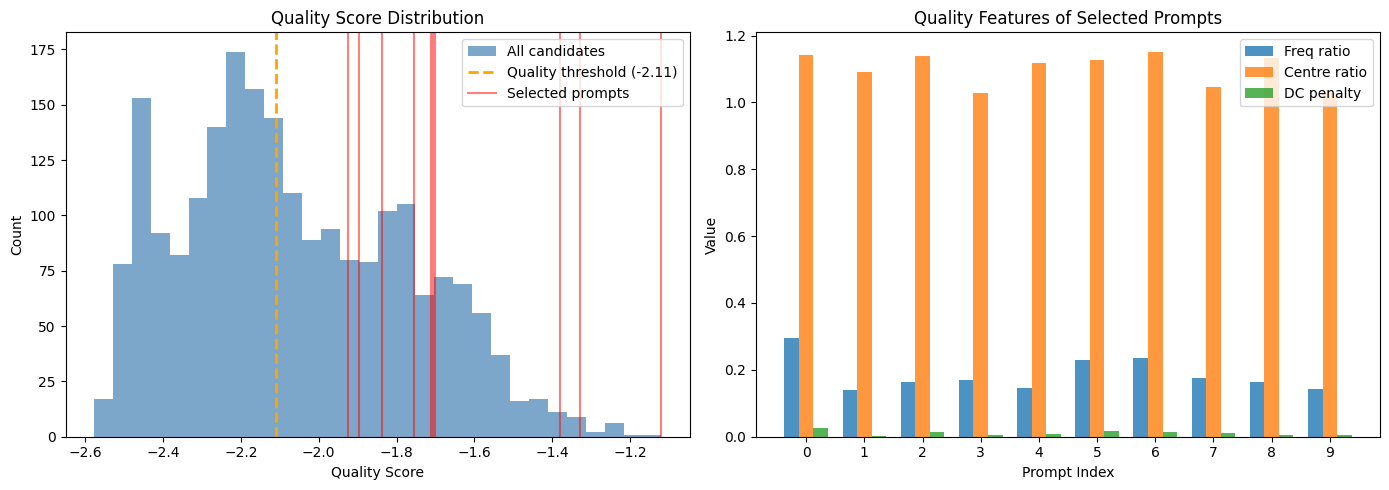


Selected prompts quality statistics:
  Quality score: mean=-1.636, std=0.254, range=[-1.925, -1.120]
  Freq ratio:    mean=0.185, range=[0.139, 0.294]
  Centre ratio:  mean=1.100, range=[1.028, 1.152]
  DC penalty:    mean=0.0108, range=[0.0023, 0.0248]


In [9]:
# Visualize quality score distribution and selection
print("=" * 70)
print("QUALITY SCORE DISTRIBUTION")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of quality scores
ax1 = axes[0]
all_scores = quality_info['all_scores']
valid_scores = all_scores[~np.isnan(all_scores)]
selected_scores = df_selected['quality_score'].values

ax1.hist(valid_scores, bins=30, alpha=0.7, label='All candidates', color='steelblue')
ax1.axvline(quality_info['threshold'], color='orange', linestyle='--', linewidth=2, 
            label=f'Quality threshold ({quality_info["threshold"]:.2f})')
for i, score in enumerate(selected_scores):
    label = 'Selected prompts' if i == 0 else None
    ax1.axvline(score, color='red', alpha=0.5, linewidth=1.5, label=label)

ax1.set_xlabel('Quality Score')
ax1.set_ylabel('Count')
ax1.set_title('Quality Score Distribution')
ax1.legend()

# Plot 2: Quality features of selected prompts
ax2 = axes[1]
selected_features = quality_info['selected_features']
freq_ratios = [f['freq_ratio'] for f in selected_features]
centre_ratios = [f['centre_ratio'] for f in selected_features]
dc_penalties = [f['dc_penalty'] for f in selected_features]

x = np.arange(len(selected_features))
width = 0.25

bars1 = ax2.bar(x - width, freq_ratios, width, label='Freq ratio', alpha=0.8)
bars2 = ax2.bar(x, centre_ratios, width, label='Centre ratio', alpha=0.8)
bars3 = ax2.bar(x + width, dc_penalties, width, label='DC penalty', alpha=0.8)

ax2.set_xlabel('Prompt Index')
ax2.set_ylabel('Value')
ax2.set_title('Quality Features of Selected Prompts')
ax2.set_xticks(x)
ax2.legend()

plt.tight_layout()
plt.savefig(str(EXP4_RESULTS_DIR / 'quality_score_distribution.png'), dpi=150)
plt.show()

# Print summary statistics
print(f"\nSelected prompts quality statistics:")
print(f"  Quality score: mean={np.mean(selected_scores):.3f}, "
      f"std={np.std(selected_scores):.3f}, "
      f"range=[{np.min(selected_scores):.3f}, {np.max(selected_scores):.3f}]")
print(f"  Freq ratio:    mean={np.mean(freq_ratios):.3f}, range=[{np.min(freq_ratios):.3f}, {np.max(freq_ratios):.3f}]")
print(f"  Centre ratio:  mean={np.mean(centre_ratios):.3f}, range=[{np.min(centre_ratios):.3f}, {np.max(centre_ratios):.3f}]")
print(f"  DC penalty:    mean={np.mean(dc_penalties):.4f}, range=[{np.min(dc_penalties):.4f}, {np.max(dc_penalties):.4f}]")

ANGULAR DISTANCE MATRIX


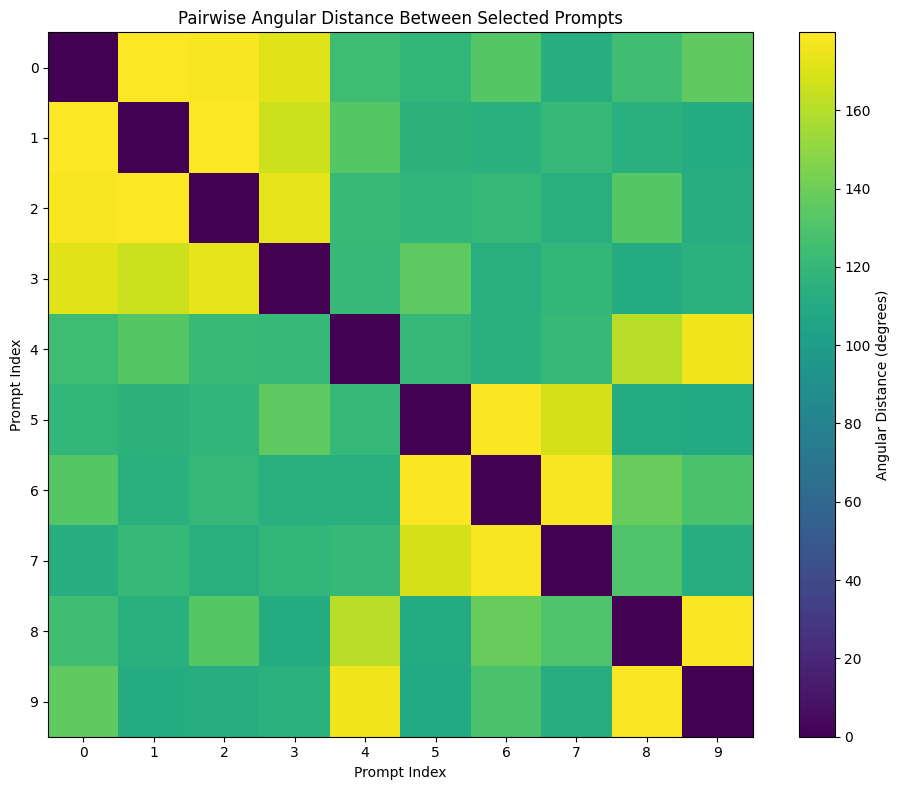


Angular distance statistics:
  Min: 109.8°
  Max: 179.9°
  Mean: 134.7°
  Std: 25.0°


In [10]:
# Visualize the angular distances between selected particles
print("=" * 70)
print("ANGULAR DISTANCE MATRIX")
print("=" * 70)

quats_selected = df_selected[['Q1', 'Q2', 'Q3', 'Q4']].values
n_selected = len(quats_selected)

dist_matrix = np.zeros((n_selected, n_selected))
for i in range(n_selected):
    for j in range(n_selected):
        dist_matrix[i, j] = quaternion_angular_distance(quats_selected[i], quats_selected[j])

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(dist_matrix, cmap='viridis')
plt.colorbar(im, label='Angular Distance (degrees)')

ax.set_xlabel('Prompt Index')
ax.set_ylabel('Prompt Index')
ax.set_title('Pairwise Angular Distance Between Selected Prompts')
ax.set_xticks(range(n_selected))
ax.set_yticks(range(n_selected))

plt.tight_layout()
plt.savefig(str(EXP4_RESULTS_DIR / 'angular_distance_matrix.png'), dpi=150)
plt.show()

# Statistics
upper_tri = dist_matrix[np.triu_indices(n_selected, k=1)]
print(f"\nAngular distance statistics:")
print(f"  Min: {upper_tri.min():.1f}°")
print(f"  Max: {upper_tri.max():.1f}°")
print(f"  Mean: {upper_tri.mean():.1f}°")
print(f"  Std: {upper_tri.std():.1f}°")

## Step 3: Extract Subtomograms and Generate Prompt Embeddings

In [11]:
print("=" * 70)
print("EXTRACTING SUBTOMOGRAMS FOR SELECTED PROMPTS")
print("=" * 70)

def extract_subtomogram(tomo, x, y, z, patch_size=37):
    """Extract a subtomogram centered at (x, y, z)."""
    half = patch_size // 2
    x, y, z = int(x), int(y), int(z)
    
    # tomo is (Z, Y, X) but coords are (X, Y, Z)
    subtomo = tomo[z-half:z+half+1, y-half:y+half+1, x-half:x+half+1]
    
    if subtomo.shape != (patch_size, patch_size, patch_size):
        return None
    
    return subtomo

# Extract subtomograms
subtomos = []
prompt_info = []

# Cache loaded tomograms
tomo_cache = {}

for idx, row in df_selected.iterrows():
    tomo_name = row['tomo_name']
    # Use voxel coordinates (converted from Angstroms in previous step)
    x, y, z = row['X_voxel'], row['Y_voxel'], row['Z_voxel']
    
    # Load tomogram if not cached
    if tomo_name not in tomo_cache:
        tomo_path = UMU_SYNTH_TOMOS_DIR / f"{tomo_name}.mrc"
        if tomo_path.exists():
            print(f"  Loading {tomo_name}...")
            tomo_cache[tomo_name] = load_mrc_data(str(tomo_path)).float()
        else:
            print(f"  ❌ Tomogram not found: {tomo_path}")
            continue
    
    tomo = tomo_cache[tomo_name]
    subtomo = extract_subtomogram(tomo, x, y, z, PROMPT_SIZE)
    
    if subtomo is not None:
        subtomos.append(subtomo)
        prompt_info.append({
            'tomo_name': tomo_name,
            'x': x, 'y': y, 'z': z,
            'q1': row['Q1'], 'q2': row['Q2'], 'q3': row['Q3'], 'q4': row['Q4']
        })
        print(f"  ✅ Extracted prompt {len(subtomos)} from {tomo_name} at ({x:.0f}, {y:.0f}, {z:.0f})")
    else:
        print(f"  ❌ Failed to extract from {tomo_name} at ({x:.0f}, {y:.0f}, {z:.0f})")

# Clear cache
del tomo_cache

print(f"\n✅ Extracted {len(subtomos)} subtomograms")

EXTRACTING SUBTOMOGRAMS FOR SELECTED PROMPTS
  Loading tomo_rec_4_snr1.85...
  ✅ Extracted prompt 1 from tomo_rec_4_snr1.85 at (441, 510, 42)
  Loading tomo_rec_11_snr1.41...
  ✅ Extracted prompt 2 from tomo_rec_11_snr1.41 at (120, 25, 64)
  Loading tomo_rec_1_snr1.46...
  ✅ Extracted prompt 3 from tomo_rec_1_snr1.46 at (37, 160, 24)
  Loading tomo_rec_0_snr1.63...
  ✅ Extracted prompt 4 from tomo_rec_0_snr1.63 at (51, 353, 143)
  ✅ Extracted prompt 5 from tomo_rec_0_snr1.63 at (411, 108, 70)
  ✅ Extracted prompt 6 from tomo_rec_0_snr1.63 at (502, 191, 131)
  ✅ Extracted prompt 7 from tomo_rec_4_snr1.85 at (215, 550, 109)
  Loading tomo_rec_19_snr1.62...
  ✅ Extracted prompt 8 from tomo_rec_19_snr1.62 at (43, 263, 100)
  ✅ Extracted prompt 9 from tomo_rec_0_snr1.63 at (573, 358, 161)
  Loading tomo_rec_15_snr1.03...
  ✅ Extracted prompt 10 from tomo_rec_15_snr1.03 at (134, 515, 134)

✅ Extracted 10 subtomograms


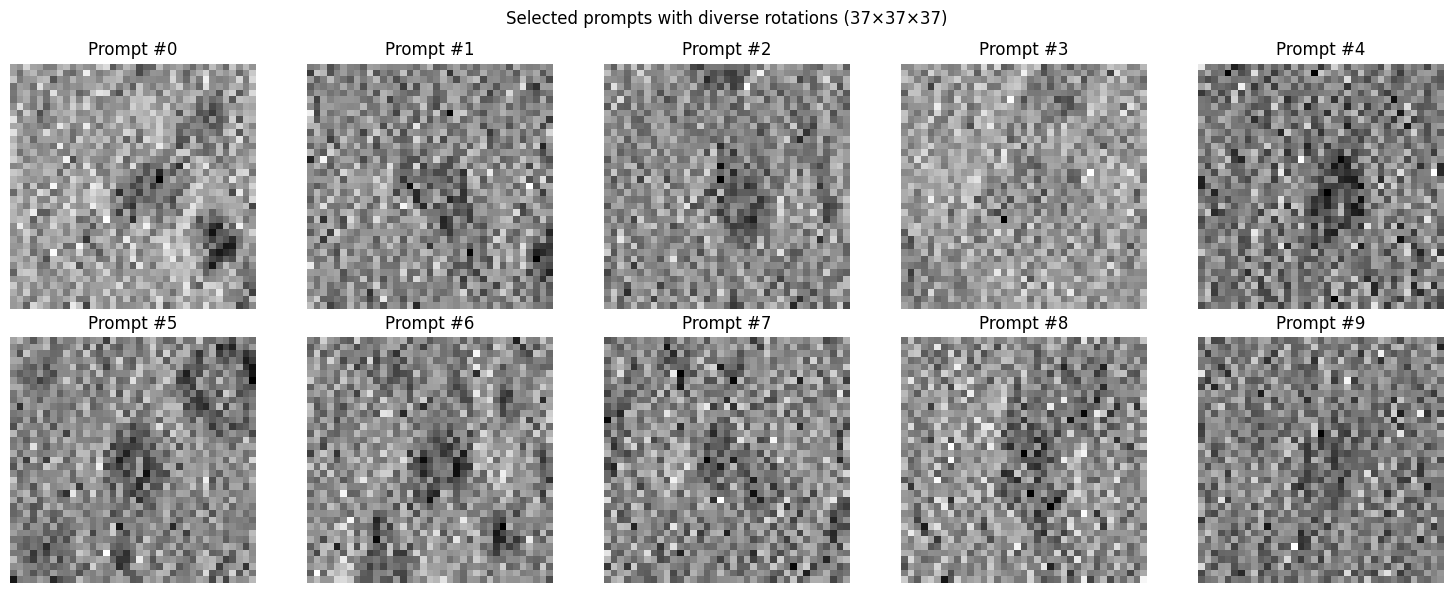

In [12]:
# Visualize extracted subtomograms
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    if i < len(subtomos):
        subtomo = subtomos[i]
        if isinstance(subtomo, torch.Tensor):
            subtomo = subtomo.numpy()
        central_slice = subtomo[PROMPT_SIZE // 2]
        ax.imshow(central_slice, cmap='gray')
        ax.set_title(f"Prompt #{i}")
    ax.axis('off')

plt.suptitle(f"Selected prompts with diverse rotations ({PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE})")
plt.tight_layout()
plt.savefig(str(EXP4_RESULTS_DIR / 'selected_prompts_visualization.png'), dpi=150)
plt.show()

In [13]:
print("=" * 70)
print("GENERATING PROMPT EMBEDDINGS WITH TOMOTWIN")
print("=" * 70)

# Convert to tensor
subtomos_tensor = torch.stack([
    torch.tensor(s) if not isinstance(s, torch.Tensor) else s 
    for s in subtomos
])

print(f"Input shape: {subtomos_tensor.shape}")

# Generate embeddings
embeddings = pass_subtomos_through_tomotwin(
    subtomos_tensor, 
    str(TOMOTWIN_MODEL_FILE)
)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Embedding dimension: {embeddings.shape[1]}")

GENERATING PROMPT EMBEDDINGS WITH TOMOTWIN
Input shape: torch.Size([10, 37, 37, 37])


Passing subtomos through TomoTwin: 100%|█████████████████████| 1/1 [00:00<00:00,  2.30it/s]

Embeddings shape: torch.Size([10, 32])
Embedding dimension: 32


In [14]:
# Save individual prompt embeddings as JSON files
print("=" * 70)
print("SAVING PROMPT EMBEDDINGS")
print("=" * 70)

for i in range(len(embeddings)):
    prompt_data = {
        THYROGLOBULIN_NAME: embeddings[i].tolist(),
        "metadata": {
            "prompt_index": i,
            "tomo_name": prompt_info[i]['tomo_name'],
            "coords": [prompt_info[i]['x'], prompt_info[i]['y'], prompt_info[i]['z']],
            "quaternion": [
                prompt_info[i]['q1'], prompt_info[i]['q2'],
                prompt_info[i]['q3'], prompt_info[i]['q4']
            ]
        }
    }
    
    prompt_file = EXP4_PROMPTS_DIR / f"prompt_{i:02d}.json"
    with open(prompt_file, 'w') as f:
        json.dump(prompt_data, f, indent=2)
    
    print(f"  ✅ Saved: {prompt_file.name}")

# Also save combined file with all embeddings
all_prompts = {
    "prompts": [
        {
            "index": i,
            "embedding": embeddings[i].tolist(),
            "metadata": prompt_info[i]
        }
        for i in range(len(embeddings))
    ]
}

all_prompts_file = EXP4_PROMPTS_DIR / "all_rotation_prompts.json"
with open(all_prompts_file, 'w') as f:
    json.dump(all_prompts, f, indent=2)

print(f"\n✅ Saved combined prompts to: {all_prompts_file}")

SAVING PROMPT EMBEDDINGS
  ✅ Saved: prompt_00.json
  ✅ Saved: prompt_01.json
  ✅ Saved: prompt_02.json
  ✅ Saved: prompt_03.json
  ✅ Saved: prompt_04.json
  ✅ Saved: prompt_05.json
  ✅ Saved: prompt_06.json
  ✅ Saved: prompt_07.json
  ✅ Saved: prompt_08.json
  ✅ Saved: prompt_09.json

✅ Saved combined prompts to: /home/carloshg/Dev/cryoet-particle-picking/results/exp4_ppicker_rotations/prompts/all_rotation_prompts.json


## Step 4: Copy Ground Truth Coordinates

Copy ground truth coordinates from EXP3 for evaluation.

In [15]:
import shutil

print("=" * 70)
print("COPYING GROUND TRUTH COORDINATES")
print("=" * 70)

for tomo_name in EXP4_VAL_TOMOS:
    src_file = EXP3_COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    dst_file = EXP4_COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    
    if src_file.exists():
        shutil.copy(src_file, dst_file)
        df_gt = pd.read_csv(src_file)
        print(f"  ✅ {tomo_name}: {len(df_gt)} particles")
    else:
        print(f"  ❌ {tomo_name}: source file not found")

print(f"\n✅ Ground truth coordinates copied to: {EXP4_COORDS_DIR}")

COPYING GROUND TRUTH COORDINATES
  ✅ tomo_rec_5_snr1.66: 127 particles
  ✅ tomo_rec_6_snr1.17: 120 particles
  ✅ tomo_rec_7_snr1.13: 133 particles
  ✅ tomo_rec_8_snr0.57: 115 particles
  ✅ tomo_rec_9_snr1.28: 127 particles

✅ Ground truth coordinates copied to: /home/carloshg/Dev/cryoet-particle-picking/results/exp4_ppicker_rotations/coords


## Step 5: Run Inference

Run inference using the generated prompts. This can be done either:
1. From the command line using the inference script
2. Programmatically from this notebook

The inference script will run for:
- Base model (no fine-tuning)
- Single-prompt fine-tuned models (increments 1, 2, 4, 8, 12, 16, 20)
- Multi-prompt fine-tuned models (increments 1, 2, 4, 8, 12, 16, 20)

In [16]:
# Display command to run inference
print("=" * 70)
print("INFERENCE COMMAND")
print("=" * 70)

inference_script = PROJECT_ROOT / "experiments" / "exp4_ppicker_rotations" / "scripts" / "umusynth_inference.py"

print(f"\nTo run inference, execute the following commands:")
print(f"\n  cd {PROJECT_ROOT / 'tools' / 'ProPicker'}")
print(f"  conda activate deepetpicker")
print(f"\n  # Run all inferences (base + all increments × all prompts):")
print(f"  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference.py")
print(f"\n  # Or run specific configurations:")
print(f"  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference.py --checkpoint-type base")
print(f"  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference.py --checkpoint-type single --increment 8")
print(f"  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference.py --checkpoint-type multi --increment 8")

INFERENCE COMMAND

To run inference, execute the following commands:

  cd /home/carloshg/Dev/cryoet-particle-picking/tools/ProPicker
  conda activate deepetpicker

  # Run all inferences (base + all increments × all prompts):
  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference.py

  # Or run specific configurations:
  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference.py --checkpoint-type base
  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference.py --checkpoint-type single --increment 8
  python ../../experiments/exp4_ppicker_rotations/scripts/umusynth_inference.py --checkpoint-type multi --increment 8


## Step 6: Load and Analyze Results

After running inference, analyze the results to compare performance across prompts and checkpoints.

In [ ]:
import glob

print("=" * 70)
print("LOADING INFERENCE RESULTS")
print("=" * 70)

# Check for inference results
inference_dir = EXP4_RESULTS_DIR / "inference"

if not inference_dir.exists():
    print(f"❌ Inference directory not found: {inference_dir}")
    print("   Run the inference script first.")
else:
    result_dirs = sorted(inference_dir.glob("*"))
    print(f"Found {len(result_dirs)} inference results:")
    for d in result_dirs:
        if d.is_dir():
            coords_dir = d / "PredictedLabels" / "Coords_All"
            if coords_dir.exists():
                n_files = len(list(coords_dir.glob("*.csv")))
                print(f"  ✅ {d.name}: {n_files} coordinate files")
            else:
                print(f"  ⏳ {d.name}: no coordinates yet")

In [ ]:
def compute_metrics(pred_coords, gt_coords, distance_threshold=15.0):
    """
    Compute precision, recall, and F1 score.
    
    Args:
        pred_coords: Predicted coordinates (N, 3)
        gt_coords: Ground truth coordinates (M, 3)
        distance_threshold: Maximum distance for a match (pixels)
        
    Returns:
        dict with precision, recall, f1, tp, fp, fn
    """
    if len(pred_coords) == 0:
        return {'precision': 0, 'recall': 0, 'f1': 0, 'tp': 0, 'fp': 0, 'fn': len(gt_coords)}
    
    if len(gt_coords) == 0:
        return {'precision': 0, 'recall': 0, 'f1': 0, 'tp': 0, 'fp': len(pred_coords), 'fn': 0}
    
    # Compute distance matrix
    distances = cdist(pred_coords, gt_coords)
    
    # Match predictions to ground truth (greedy)
    tp = 0
    matched_gt = set()
    
    for i in range(len(pred_coords)):
        min_dist = float('inf')
        best_j = -1
        
        for j in range(len(gt_coords)):
            if j not in matched_gt and distances[i, j] < min_dist:
                min_dist = distances[i, j]
                best_j = j
        
        if best_j != -1 and min_dist <= distance_threshold:
            tp += 1
            matched_gt.add(best_j)
    
    fp = len(pred_coords) - tp
    fn = len(gt_coords) - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn
    }


def load_predicted_coords(result_dir, tomo_name):
    """
    Load predicted coordinates from a result directory.
    """
    coords_file = result_dir / "PredictedLabels" / "Coords_All" / f"{tomo_name}_{THYROGLOBULIN_NAME}.csv"
    
    if coords_file.exists():
        df = pd.read_csv(coords_file)
        if 'x' in df.columns:
            return df[['x', 'y', 'z']].values
        elif 'X' in df.columns:
            return df[['X', 'Y', 'Z']].values
    
    return np.array([]).reshape(0, 3)


def load_gt_coords(tomo_name):
    """Load ground truth coordinates."""
    coords_file = EXP4_COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    
    if coords_file.exists():
        df = pd.read_csv(coords_file)
        return df[['X', 'Y', 'Z']].values
    
    return np.array([]).reshape(0, 3)

In [ ]:
print("=" * 70)
print("COMPUTING METRICS FOR ALL RESULTS")
print("=" * 70)

all_results = []

inference_dir = EXP4_RESULTS_DIR / "inference"

if inference_dir.exists():
    for result_dir in sorted(inference_dir.glob("*")):
        if not result_dir.is_dir():
            continue
        
        # Parse result name: base_promptX or {single,multi}_incY_promptX
        name = result_dir.name
        
        if name.startswith("base_"):
            checkpoint_type = "base"
            increment = 0
            prompt_idx = int(name.split("prompt")[1])
        else:
            parts = name.split("_")
            checkpoint_type = parts[0]
            increment = int(parts[1].replace("inc", ""))
            prompt_idx = int(parts[2].replace("prompt", ""))
        
        # Compute metrics for each validation tomogram
        for tomo_name in EXP4_VAL_TOMOS:
            pred_coords = load_predicted_coords(result_dir, tomo_name)
            gt_coords = load_gt_coords(tomo_name)
            
            if len(gt_coords) == 0:
                continue
            
            metrics = compute_metrics(pred_coords, gt_coords)
            
            all_results.append({
                'checkpoint_type': checkpoint_type,
                'increment': increment,
                'prompt_idx': prompt_idx,
                'tomo_name': tomo_name,
                **metrics
            })

if all_results:
    df_results = pd.DataFrame(all_results)
    print(f"\n✅ Computed metrics for {len(df_results)} configurations")
    df_results.head(10)
else:
    print("❌ No results found. Run inference first.")
    df_results = pd.DataFrame()

In [ ]:
# Skip analysis if no results
if len(df_results) == 0:
    print("⏳ Skipping analysis - run inference first")
else:
    # Aggregate metrics per checkpoint type and prompt
    print("=" * 70)
    print("AGGREGATED RESULTS")
    print("=" * 70)
    
    # Group by checkpoint type and prompt
    df_agg = df_results.groupby(['checkpoint_type', 'increment', 'prompt_idx']).agg({
        'precision': ['mean', 'std'],
        'recall': ['mean', 'std'],
        'f1': ['mean', 'std'],
        'tp': 'sum',
        'fp': 'sum',
        'fn': 'sum'
    }).round(3)
    
    print("\nMetrics per checkpoint and prompt:")
    display(df_agg)

## Step 7: Comparison Analysis

Compare performance across:
1. Base vs Single-prompt increments
2. Base vs Multi-prompt increments
3. Single-prompt vs Multi-prompt increments

In [ ]:
if len(df_results) == 0:
    print("⏳ Skipping comparison - run inference first")
else:
    print("=" * 70)
    print("COMPARISON: ROTATION INVARIANCE ANALYSIS")
    print("=" * 70)
    
    # Compute F1 variance per checkpoint type to measure rotation sensitivity
    df_variance = df_results.groupby(['checkpoint_type', 'increment']).agg({
        'f1': ['mean', 'std', 'min', 'max']
    }).round(3)
    df_variance.columns = ['f1_mean', 'f1_std', 'f1_min', 'f1_max']
    df_variance['f1_range'] = df_variance['f1_max'] - df_variance['f1_min']
    
    print("\nF1 Score variance across prompts (lower std = more rotation invariant):")
    display(df_variance.sort_values('f1_std'))
    
    # Save results
    df_results.to_csv(EXP4_RESULTS_DIR / 'inference_all_results.csv', index=False)
    df_variance.to_csv(EXP4_RESULTS_DIR / 'rotation_invariance_summary.csv')
    print(f"\n✅ Results saved to {EXP4_RESULTS_DIR}")

In [ ]:
if len(df_results) == 0:
    print("⏳ Skipping visualization - run inference first")
else:
    # Visualize F1 distribution per checkpoint type
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Base model
    ax = axes[0]
    df_base = df_results[df_results['checkpoint_type'] == 'base']
    if len(df_base) > 0:
        sns.boxplot(data=df_base, x='prompt_idx', y='f1', ax=ax)
        ax.set_title('Base Model')
        ax.set_xlabel('Prompt Index')
        ax.set_ylabel('F1 Score')
        ax.set_ylim(0, 1)
    
    # 2. Single-prompt models
    ax = axes[1]
    df_single = df_results[df_results['checkpoint_type'] == 'single']
    if len(df_single) > 0:
        # Average across increments for each prompt
        df_single_avg = df_single.groupby('prompt_idx')['f1'].mean().reset_index()
        sns.barplot(data=df_single_avg, x='prompt_idx', y='f1', ax=ax)
        ax.set_title('Single-Prompt Models (avg over increments)')
        ax.set_xlabel('Prompt Index')
        ax.set_ylabel('F1 Score')
        ax.set_ylim(0, 1)
    
    # 3. Multi-prompt models
    ax = axes[2]
    df_multi = df_results[df_results['checkpoint_type'] == 'multi']
    if len(df_multi) > 0:
        df_multi_avg = df_multi.groupby('prompt_idx')['f1'].mean().reset_index()
        sns.barplot(data=df_multi_avg, x='prompt_idx', y='f1', ax=ax)
        ax.set_title('Multi-Prompt Models (avg over increments)')
        ax.set_xlabel('Prompt Index')
        ax.set_ylabel('F1 Score')
        ax.set_ylim(0, 1)
    
    plt.suptitle('F1 Score Distribution Across Rotation-Diverse Prompts')
    plt.tight_layout()
    plt.savefig(str(EXP4_RESULTS_DIR / 'f1_by_prompt_comparison.png'), dpi=150)
    plt.show()

In [ ]:
if len(df_results) == 0:
    print("⏳ Skipping visualization - run inference first")
else:
    # Heatmap: F1 score by increment and prompt
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax, ckpt_type in zip(axes, ['single', 'multi']):
        df_type = df_results[df_results['checkpoint_type'] == ckpt_type]
        if len(df_type) > 0:
            # Pivot to create heatmap
            df_pivot = df_type.groupby(['increment', 'prompt_idx'])['f1'].mean().unstack()
            
            sns.heatmap(df_pivot, annot=True, fmt='.2f', cmap='RdYlGn', 
                       vmin=0, vmax=1, ax=ax)
            ax.set_title(f'{ckpt_type.capitalize()}-Prompt Models')
            ax.set_xlabel('Prompt Index')
            ax.set_ylabel('Training Increment')
    
    plt.suptitle('F1 Score Heatmap: Increment × Prompt (Rotation)')
    plt.tight_layout()
    plt.savefig(str(EXP4_RESULTS_DIR / 'f1_heatmap_increment_prompt.png'), dpi=150)
    plt.show()

In [ ]:
if len(df_results) == 0:
    print("⏳ Skipping statistical analysis - run inference first")
else:
    # Statistical comparison between checkpoint types
    print("=" * 70)
    print("STATISTICAL COMPARISON")
    print("=" * 70)
    
    from scipy import stats
    
    # Compare F1 distributions
    comparisons = [
        ('base', 'single', 'Base vs Single-Prompt'),
        ('base', 'multi', 'Base vs Multi-Prompt'),
        ('single', 'multi', 'Single vs Multi-Prompt'),
    ]
    
    print("\nMann-Whitney U test for F1 scores:")
    print("-" * 60)
    
    for type1, type2, label in comparisons:
        f1_1 = df_results[df_results['checkpoint_type'] == type1]['f1'].values
        f1_2 = df_results[df_results['checkpoint_type'] == type2]['f1'].values
        
        if len(f1_1) > 0 and len(f1_2) > 0:
            stat, pval = stats.mannwhitneyu(f1_1, f1_2, alternative='two-sided')
            print(f"\n{label}:")
            print(f"  {type1}: mean={f1_1.mean():.3f}, std={f1_1.std():.3f}")
            print(f"  {type2}: mean={f1_2.mean():.3f}, std={f1_2.std():.3f}")
            print(f"  p-value: {pval:.4f} {'(significant)' if pval < 0.05 else '(not significant)'}")

## Summary

This notebook:
1. ✅ Selected 10 prompts with diverse rotations from the CSV
2. ✅ Generated TomoTwin embeddings for each prompt
3. ⏳ Run inference for base, single-prompt, and multi-prompt models
4. ⏳ Compared performance across different rotations

### Key Findings

After running inference, examine:
- **F1 std**: Lower standard deviation across prompts indicates better rotation invariance
- **F1 range**: Smaller range (max - min) indicates more consistent performance
- **Comparison**: Which model type is most rotation invariant?